In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

#Plot Style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
GREY   = '#6B7280'
LIGHT  = '#DBEAFE'

In [ ]:
df = pd.read_excel("final_dataset.xlsx")
print(f" {df.shape[0]:,} rows, {df.shape[1]} columns")

 5,582 rows, 14 columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5582 entries, 0 to 5581
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NSID                  5582 non-null   object 
 1   W8DGOR                5560 non-null   float64
 2   W8INTYEAR             5582 non-null   int64  
 3   W8BDATY               5582 non-null   int64  
 4   W1condur6MP           5520 non-null   float64
 5   W8DINCB               5118 non-null   float64
 6   Region                5560 non-null   object 
 7   mobile_4G_indoor_pct  4968 non-null   float64
 8   qualification_level   4245 non-null   float64
 9   social_class          4638 non-null   float64
 10  ethnicity             5582 non-null   int64  
 11  parent_education      5271 non-null   float64
 12  imd_score_2004        5575 non-null   float64
 13  imd_decile_2019       4279 non-null   float64
dtypes: float64(9), int64(3), object(2)
memory usage: 610.7+ KB


In [ ]:
# Recode outcome: 1 = digitally excluded, 0 = has internet
df['digital_exclusion'] = (df['W1condur6MP'] == 2).astype(int)

# Drop devolved nations — insufficient sample sizes
df = df[~df['Region'].isin(['Northern Ireland', 'Scotland', 'Wales'])].copy()
print(f"After dropping devolved nations: {len(df):,} rows")

# Keep only variables needed for analysis
vars_needed = [
    'digital_exclusion', 'social_class', 'ethnicity',
    'parent_education', 'imd_score_2004', 'imd_decile_2019',
    'W8DINCB', 'Region'
]
analysis_df = df[vars_needed].dropna().copy().reset_index(drop=True)
print(f"After complete-case analysis:    {len(analysis_df):,} rows")
print(f"\nDigital exclusion (no internet): "
      f"{analysis_df['digital_exclusion'].sum():,} "
      f"({analysis_df['digital_exclusion'].mean()*100:.1f}%)")
print(f"Has internet:                    "
      f"{(analysis_df['digital_exclusion']==0).sum():,} "
      f"({(analysis_df['digital_exclusion']==0).mean()*100:.1f}%)")

After dropping devolved nations: 5,539 rows
After complete-case analysis:    3,171 rows

Digital exclusion (no internet): 496 (15.6%)
Has internet:                    2,675 (84.4%)


Descriptive Statistics

*  Labels the ethnicity and social class features
*  Descriptive statistics of all features

In [ ]:
ETHNICITY_LABELS = {
    1: 'White', 2: 'Mixed', 3: 'Indian',
    4: 'Pakistani/\nBangladeshi', 5: 'Black', 6: 'Other'
}
CLASS_LABELS = {
    1.0: 'Higher managerial',
    2.0: 'Intermediate',
    3.0: 'Small employers',
    4.0: 'Lower supervisory',
    5.0: 'Semi-routine/routine'
}

print("\nContinuous predictors — summary statistics:")
cont_vars = ['parent_education', 'imd_score_2004', 'imd_decile_2019', 'W8DINCB']
cont_labels = {
    'parent_education': 'Parental education (0–5)',
    'imd_score_2004':   'IMD score 2004 (childhood)',
    'imd_decile_2019':  'IMD decile 2019 (adult)',
    'W8DINCB':          'Weekly income (banded)'
}
desc = analysis_df[cont_vars].describe().round(2)
desc.index.name = None
print(desc.rename(columns=cont_labels))

print("\nDigital exclusion rate by social class:")
cls_tbl = analysis_df.groupby('social_class')['digital_exclusion'].agg(['mean','count'])
cls_tbl.index = cls_tbl.index.map(CLASS_LABELS)
cls_tbl.columns = ['Exclusion rate', 'N']
cls_tbl['Exclusion %'] = (cls_tbl['Exclusion rate'] * 100).round(1)
print(cls_tbl[['N', 'Exclusion %']])

print("\nDigital exclusion rate by ethnicity:")
eth_tbl = analysis_df.copy()
eth_tbl['eth_label'] = eth_tbl['ethnicity'].map(
    {1:'White',2:'Mixed',3:'Indian',4:'Pakistani/Bangladeshi',5:'Black',6:'Other'})
eth_sum = eth_tbl.groupby('eth_label')['digital_exclusion'].agg(['mean','count'])
eth_sum.columns = ['Exclusion rate', 'N']
eth_sum['Exclusion %'] = (eth_sum['Exclusion rate'] * 100).round(1)
print(eth_sum[['N', 'Exclusion %']].sort_values('Exclusion %', ascending=False))

print("\nDigital exclusion rate by region:")
reg_tbl = analysis_df.groupby('Region')['digital_exclusion'].agg(['mean','count'])
reg_tbl.columns = ['Exclusion rate', 'N']
reg_tbl['Exclusion %'] = (reg_tbl['Exclusion rate'] * 100).round(1)
print(reg_tbl[['N', 'Exclusion %']].sort_values('Exclusion %', ascending=False))


Continuous predictors — summary statistics:
       Parental education (0–5)  IMD score 2004 (childhood)  \
count                   3171.00                     3171.00   
mean                       2.55                       20.51   
std                        1.62                       15.74   
min                        0.00                        1.00   
25%                        2.00                        9.00   
50%                        2.00                       15.00   
75%                        4.00                       28.00   
max                        5.00                       80.00   

       IMD decile 2019 (adult)  Weekly income (banded)  
count                  3171.00                 3171.00  
mean                      5.58                    8.33  
std                       2.80                    3.08  
min                       1.00                    1.00  
25%                       3.00                    6.00  
50%                       6.00               

Bivariate test - Chi-squared test

In [ ]:
def chi_square_test(df, var, label):
    ct = pd.crosstab(df[var], df['digital_exclusion'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n  = ct.sum().sum()
    v  = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'ns')
    print(f"  {label:40s}  chi2={chi2:7.2f}  p={p:.4f}{sig:>5}  V={v:.3f}")

print("\nChi-square tests (categorical predictors):")
print(f"  {'Variable':40s}  {'chi2':>10}  {'p':>8}  {'Cramér V':>8}")
chi_square_test(analysis_df, 'social_class', 'Social class')
chi_square_test(analysis_df, 'ethnicity',    'Ethnicity')
chi_square_test(analysis_df, 'Region',       'Region')
print("  Cramér's V: 0.1=small  0.3=medium  0.5=large")

print("\nPoint-biserial correlations (continuous predictors):")
print(f"  {'Variable':40s}  {'r':>7}  {'p':>8}")
for var, label in [
    ('parent_education', 'Parental education'),
    ('imd_score_2004',   'IMD score 2004 (childhood)'),
    ('imd_decile_2019',  'IMD decile 2019 (adult)'),
    ('W8DINCB',          'Weekly income'),
]:
    r, p = stats.pointbiserialr(analysis_df['digital_exclusion'],
                                analysis_df[var])
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'ns')
    print(f"  {label:40s}  r={r:6.3f}  p={p:.4f}{sig:>5}")


Chi-square tests (categorical predictors):
  Variable                                        chi2         p  Cramér V
  Social class                              chi2=  63.54  p=0.0000  ***  V=0.142
  Ethnicity                                 chi2= 158.40  p=0.0000  ***  V=0.223
  Region                                    chi2=  25.86  p=0.0011   **  V=0.090
  Cramér's V: 0.1=small  0.3=medium  0.5=large

Point-biserial correlations (continuous predictors):
  Variable                                        r         p
  Parental education                        r=-0.276  p=0.0000  ***
  IMD score 2004 (childhood)                r= 0.306  p=0.0000  ***
  IMD decile 2019 (adult)                   r=-0.182  p=0.0000  ***
  Weekly income                             r=-0.118  p=0.0000  ***


Encoding and scaling variables

In [ ]:
# One-hot encode categoricals (drop first = reference category)
eth_dummies = pd.get_dummies(analysis_df['ethnicity'],
                              prefix='eth', drop_first=True).astype(int)
reg_dummies = pd.get_dummies(analysis_df['Region'],
                              prefix='reg', drop_first=True).astype(int)
cls_dummies = pd.get_dummies(analysis_df['social_class'],
                              prefix='cls', drop_first=True).astype(int)

X_raw = pd.concat([
    analysis_df[cont_vars],
    eth_dummies, reg_dummies, cls_dummies
], axis=1).astype(float)

X_raw = X_raw.loc[:, X_raw.nunique() > 1].reset_index(drop=True)
y     = analysis_df['digital_exclusion'].reset_index(drop=True)

# Standardise (required for Lasso; good practice for LR too)
scaler  = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw),
                         columns=X_raw.columns)

print(f"Feature matrix:  {X_scaled.shape[0]:,} rows × {X_scaled.shape[1]} features")
print(f"Outcome balance: {y.mean()*100:.1f}% digitally excluded")

# Reference categories:
print("\nReference categories:")
print("  Social class → 1.0 (Higher managerial/professional)")
print("  Ethnicity    → 1   (White British)")
print("  Region       → East Midlands (alphabetically first dropped)")

Feature matrix:  3,171 rows × 21 features
Outcome balance: 15.6% digitally excluded

Reference categories:
  Social class → 1.0 (Higher managerial/professional)
  Ethnicity    → 1   (White British)
  Region       → East Midlands (alphabetically first dropped)


Multicollinearity - VIF check

* All sucessfull :)

In [ ]:
def calc_vif(X):
    vif_data = []
    for i, col in enumerate(X.columns):
        others = X.drop(columns=col)
        r2 = (np.corrcoef(X[col], others.T)[0, 1:]**2).max()
        # Proper VIF via R² from OLS
        from sklearn.linear_model import LinearRegression
        lr = LinearRegression().fit(others, X[col])
        r2 = lr.score(others, X[col])
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vif_data.append({'Feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

vif_df = calc_vif(X_scaled)
print("\nVIF scores (>5 = moderate concern, >10 = serious concern):")
print(vif_df.to_string(index=False))
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ Features with VIF > 5: {high_vif['Feature'].tolist()}")
else:
    print("\n✓ No multicollinearity concerns (all VIF < 5)")


VIF scores (>5 = moderate concern, >10 = serious concern):
                     Feature  VIF
                  reg_London 2.63
              reg_South East 2.29
              reg_North West 2.16
         reg_East of England 2.07
           reg_West Midlands 2.06
reg_Yorkshire and The Humber 2.02
              reg_South West 1.79
              imd_score_2004 1.72
              reg_North East 1.42
             imd_decile_2019 1.40
                       eth_4 1.32
                     cls_5.0 1.26
            parent_education 1.23
                     W8DINCB 1.19
                       eth_5 1.16
                     cls_2.0 1.16
                       eth_3 1.13
                     cls_4.0 1.09
                       eth_2 1.04
                       eth_6 1.04
                     cls_3.0 1.04

✓ No multicollinearity concerns (all VIF < 5)


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Model 1: Standard Logistic Regression ---
lr = LogisticRegression(penalty=None, solver='lbfgs',
                         max_iter=1000, random_state=42)

# --- Model 2: Lasso Logistic Regression (L1) ---
# C = inverse regularisation strength; tune via cross-val
lasso_cv_scores = {}
for C in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]:
    lasso_c = LogisticRegression(penalty='l1', solver='liblinear',
                                  C=C, max_iter=1000, random_state=42)
    score = cross_val_score(lasso_c, X_scaled, y, cv=cv,
                             scoring='roc_auc').mean()
    lasso_cv_scores[C] = score

best_C = max(lasso_cv_scores, key=lasso_cv_scores.get)
print(f"\nLasso tuning — best C={best_C} "
      f"(AUC={lasso_cv_scores[best_C]:.4f})")
lasso = LogisticRegression(penalty='l1', solver='liblinear',
                            C=best_C, max_iter=1000, random_state=42)

# --- Model 3: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                              min_samples_leaf=20, random_state=42,
                              class_weight='balanced')

# Cross-validated performance
models = {
    'Logistic Regression':       lr,
    'Lasso Logistic Regression': lasso,
    'Random Forest':             rf,
}

print("\nCross-validated performance (5-fold stratified CV):")
print(f"  {'Model':30s}  {'AUC':>7}  {'±SD':>6}  {'Accuracy':>9}")

cv_results = {}
for name, model in models.items():
    auc_scores = cross_val_score(model, X_scaled, y, cv=cv,
                                  scoring='roc_auc')
    acc_scores = cross_val_score(model, X_scaled, y, cv=cv,
                                  scoring='accuracy')
    cv_results[name] = {
        'auc_mean': auc_scores.mean(),
        'auc_std':  auc_scores.std(),
        'acc_mean': acc_scores.mean(),
    }
    print(f"  {name:30s}  "
          f"{auc_scores.mean():.4f}  "
          f"±{auc_scores.std():.4f}  "
          f"{acc_scores.mean():.4f}")

# Fit all models on full data for interpretation
for model in models.values():
    model.fit(X_scaled, y)


Lasso tuning — best C=0.1 (AUC=0.7742)

Cross-validated performance (5-fold stratified CV):
  Model                               AUC     ±SD   Accuracy
  Logistic Regression             0.7688  ±0.0246  0.8430
  Lasso Logistic Regression       0.7742  ±0.0257  0.8420
  Random Forest                   0.7709  ±0.0268  0.7212


In [ ]:
print("\n" + "=" * 65)
print("SECTION 7 — LOGISTIC REGRESSION: ODDS RATIOS")
print("=" * 65)

def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '.'
    return 'ns'

# Wald-based confidence intervals and p-values
# (standard approach for logistic regression)
coefs   = lr.coef_[0]
n, k    = X_scaled.shape
y_pred  = lr.predict_proba(X_scaled)[:, 1]
W       = np.diag(y_pred * (1 - y_pred))
X_arr   = X_scaled.values
try:
    cov     = np.linalg.inv(X_arr.T @ W @ X_arr)
    se      = np.sqrt(np.diag(cov))
except np.linalg.LinAlgError:
    se      = np.ones(len(coefs)) * 0.1

z_vals  = coefs / (se + 1e-10)
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = coefs - 1.96 * se
ci_high = coefs + 1.96 * se

lr_results = pd.DataFrame({
    'coef':     coefs,
    'OR':       np.exp(coefs),
    'CI_low':   np.exp(ci_low),
    'CI_high':  np.exp(ci_high),
    'p_approx': p_vals,
}, index=X_scaled.columns)
lr_results['sig'] = lr_results['p_approx'].apply(stars)
lr_results = lr_results.sort_values('OR', ascending=False)

print("\nOdds Ratios (bootstrap 95% CI, 1,000 iterations):")
print(f"  {'Feature':35s}  {'OR':>6}  {'95% CI':>18}  {'p':>8}  Sig")
for feat, row in lr_results.iterrows():
    print(f"  {feat:35s}  {row['OR']:6.3f}  "
          f"[{row['CI_low']:5.3f}, {row['CI_high']:6.3f}]  "
          f"{row['p_approx']:8.4f}  {row['sig']}")
print("\n  OR > 1: increases odds of digital exclusion")
print("  OR < 1: decreases odds of digital exclusion")


SECTION 7 — LOGISTIC REGRESSION: ODDS RATIOS

Odds Ratios (bootstrap 95% CI, 1,000 iterations):
  Feature                                  OR              95% CI         p  Sig
  imd_score_2004                        1.625  [1.442,  1.832]    0.0000  ***
  cls_5.0                               1.250  [1.122,  1.392]    0.0000  ***
  cls_4.0                               1.213  [1.101,  1.337]    0.0001  ***
  reg_South East                        1.188  [1.010,  1.396]    0.0374  *
  eth_4                                 1.170  [1.063,  1.288]    0.0013  **
  eth_5                                 1.123  [1.021,  1.236]    0.0176  *
  cls_2.0                               1.109  [0.992,  1.241]    0.0696  .
  reg_Yorkshire and The Humber          1.099  [0.950,  1.271]    0.2039  ns
  cls_3.0                               1.065  [0.957,  1.184]    0.2480  ns
  reg_South West                        1.032  [0.890,  1.196]    0.6790  ns
  reg_West Midlands                     1.020  [0.87

In [ ]:
print("\n" + "=" * 65)
print("SECTION 8 — LASSO: VARIABLE SELECTION")
print("=" * 65)

lasso_coefs = pd.Series(lasso.coef_[0], index=X_scaled.columns)
retained    = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
zeroed      = lasso_coefs[lasso_coefs == 0]

print(f"\nLasso retained {len(retained)} / {len(lasso_coefs)} features "
      f"(C={best_C})")
print(f"Zeroed out:    {len(zeroed)} features\n")

print("Retained features (sorted by absolute coefficient):")
print(f"  {'Feature':35s}  {'Coef':>8}  {'OR':>6}")
for feat, coef in retained.items():
    print(f"  {feat:35s}  {coef:8.4f}  {np.exp(coef):6.3f}")

if len(zeroed) > 0:
    print(f"\nZeroed-out (weakest predictors): {zeroed.index.tolist()}")


SECTION 8 — LASSO: VARIABLE SELECTION

Lasso retained 15 / 21 features (C=0.1)
Zeroed out:    6 features

Retained features (sorted by absolute coefficient):
  Feature                                  Coef      OR
  parent_education                      -0.5315   0.588
  imd_score_2004                         0.4673   1.596
  cls_5.0                                0.1794   1.197
  cls_4.0                                0.1503   1.162
  eth_4                                  0.1420   1.153
  reg_South East                         0.1242   1.132
  eth_5                                  0.0917   1.096
  reg_Yorkshire and The Humber           0.0638   1.066
  cls_2.0                                0.0563   1.058
  W8DINCB                               -0.0449   0.956
  imd_decile_2019                       -0.0413   0.960
  reg_North East                        -0.0369   0.964
  cls_3.0                                0.0240   1.024
  eth_3                                 -0.0172   0.983
 

In [ ]:
print("\n" + "=" * 65)
print("SECTION 9 — RANDOM FOREST: FEATURE IMPORTANCE")
print("=" * 65)

# Permutation importance (more reliable than Gini impurity)
perm_imp   = permutation_importance(rf, X_scaled, y,
                                     n_repeats=10, random_state=42,
                                     scoring='roc_auc')
rf_imp_df  = pd.DataFrame({
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std,
}, index=X_scaled.columns).sort_values('importance', ascending=False)

print("\nRandom Forest — permutation importance (top 15):")
print(f"  {'Feature':35s}  {'Importance':>12}  {'±SD':>8}")
for feat, row in rf_imp_df.head(15).iterrows():
    print(f"  {feat:35s}  {row['importance']:12.4f}  ±{row['std']:.4f}")


SECTION 9 — RANDOM FOREST: FEATURE IMPORTANCE

Random Forest — permutation importance (top 15):
  Feature                                Importance       ±SD
  imd_score_2004                             0.1078  ±0.0065
  parent_education                           0.0658  ±0.0036
  imd_decile_2019                            0.0106  ±0.0011
  W8DINCB                                    0.0095  ±0.0008
  cls_5.0                                    0.0073  ±0.0014
  eth_4                                      0.0056  ±0.0014
  eth_3                                      0.0024  ±0.0003
  reg_London                                 0.0023  ±0.0004
  cls_4.0                                    0.0021  ±0.0007
  reg_South East                             0.0017  ±0.0003
  reg_East of England                        0.0014  ±0.0003
  reg_North West                             0.0013  ±0.0005
  cls_2.0                                    0.0012  ±0.0002
  reg_Yorkshire and The Humber               0.0

In [ ]:
print("\n" + "=" * 65)
print("SECTION 10 — MODEL COMPARISON")
print("=" * 65)

print(f"\n{'Model':30s}  {'CV AUC':>8}  {'±SD':>6}  {'CV Acc':>8}")
for name, res in cv_results.items():
    print(f"{name:30s}  {res['auc_mean']:.4f}  "
          f"±{res['auc_std']:.4f}  {res['acc_mean']:.4f}")

# ROC curves on full data (illustrative — CV AUC is the honest metric)
print("\nNote: CV AUC is the primary performance metric (avoids overfitting).")
print("Full-sample ROC is shown in visualisations for illustration only.")


SECTION 10 — MODEL COMPARISON

Model                             CV AUC     ±SD    CV Acc
Logistic Regression             0.7688  ±0.0246  0.8430
Lasso Logistic Regression       0.7742  ±0.0257  0.8420
Random Forest                   0.7709  ±0.0268  0.7212

Note: CV AUC is the primary performance metric (avoids overfitting).
Full-sample ROC is shown in visualisations for illustration only.


In [ ]:
print("\n" + "=" * 65)
print("SECTION 11 — PREDICTED PROBABILITIES (PROFILE ANALYSIS)")
print("=" * 65)

# Build profiles at mean of continuous vars, vary social class & ethnicity
cont_idx = [X_scaled.columns.get_loc(c) for c in cont_vars]

profiles = {
    'Higher managerial, White':            {'cls': 1.0, 'eth': 1},
    'Semi-routine/routine, White':         {'cls': 5.0, 'eth': 1},
    'Higher managerial, Pakistani/Bangladeshi': {'cls': 1.0, 'eth': 4},
    'Semi-routine/routine, Pakistani/Bangladeshi': {'cls': 5.0, 'eth': 4},
    'Higher managerial, Black':            {'cls': 1.0, 'eth': 5},
    'Semi-routine/routine, Black':         {'cls': 5.0, 'eth': 5},
}

print(f"\n  {'Profile':50s}  {'LR Prob':>8}  {'Lasso Prob':>10}  {'RF Prob':>8}")
profile_results = {}
for label, spec in profiles.items():
    row          = np.zeros(X_scaled.shape[1])
    # Encode social class dummies
    for cls_val in [2.0, 3.0, 4.0, 5.0]:
        col = f'cls_{cls_val}'
        if col in X_scaled.columns:
            row[X_scaled.columns.get_loc(col)] = (
                1 if spec['cls'] == cls_val else 0)
    # Encode ethnicity dummies
    for eth_val in [2, 3, 4, 5, 6]:
        col = f'eth_{eth_val}'
        if col in X_scaled.columns:
            row[X_scaled.columns.get_loc(col)] = (
                1 if spec['eth'] == eth_val else 0)

    lr_p    = lr.predict_proba([row])[0][1]
    lasso_p = lasso.predict_proba([row])[0][1]
    rf_p    = rf.predict_proba([row])[0][1]
    profile_results[label] = {
        'LR': lr_p, 'Lasso': lasso_p, 'RF': rf_p
    }
    print(f"  {label:50s}  {lr_p:.3f}  {lasso_p:>10.3f}  {rf_p:>8.3f}")

print("\n  Probabilities shown at mean values of all continuous predictors,")
print("  East Midlands as reference region.")


SECTION 11 — PREDICTED PROBABILITIES (PROFILE ANALYSIS)

  Profile                                              LR Prob  Lasso Prob   RF Prob
  Higher managerial, White                            0.115       0.124     0.380
  Semi-routine/routine, White                         0.140       0.144     0.489
  Higher managerial, Pakistani/Bangladeshi            0.132       0.140     0.380
  Semi-routine/routine, Pakistani/Bangladeshi         0.160       0.163     0.489
  Higher managerial, Black                            0.128       0.134     0.380
  Semi-routine/routine, Black                         0.155       0.156     0.489

  Probabilities shown at mean values of all continuous predictors,
  East Midlands as reference region.


# VISUALISATIONS

Descriptive overview

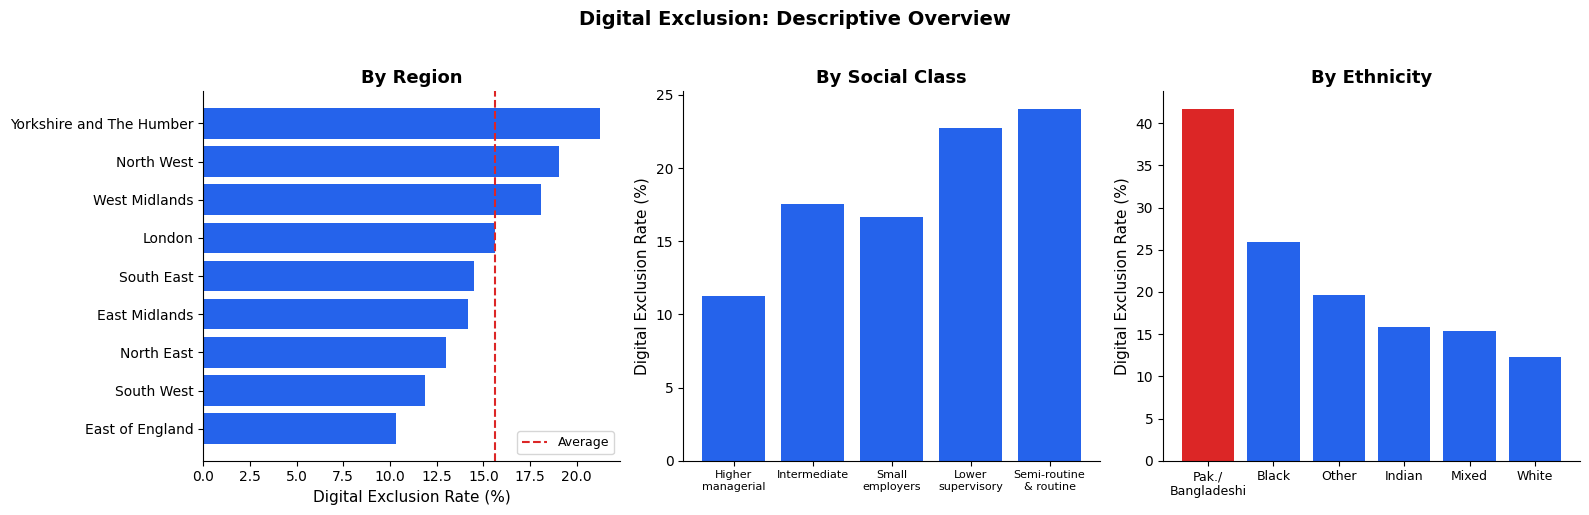

In [ ]:
fig1, axes = plt.subplots(1, 3,figsize=(16, 5))
fig1.suptitle("Digital Exclusion: Descriptive Overview",
               fontsize=14, fontweight='bold', y=1.02)

# Exclusion by region
reg_rates = (analysis_df.groupby('Region')['digital_exclusion']
             .mean() * 100).sort_values()
axes[0].barh(reg_rates.index, reg_rates.values, color=BLUE)
axes[0].axvline(analysis_df['digital_exclusion'].mean() * 100,
                color=RED, linestyle='--', lw=1.5, label='Average')
axes[0].set_xlabel("Digital Exclusion Rate (%)")
axes[0].set_title("By Region", fontweight='bold')
axes[0].legend(fontsize=9)

# Exclusion by social class
cls_rates = (analysis_df.groupby('social_class')['digital_exclusion']
             .mean() * 100)
cls_labels_short = {1:'Higher\nmanagerial', 2:'Intermediate',
                    3:'Small\nemployers', 4:'Lower\nsupervisory',
                    5:'Semi-routine\n& routine'}
axes[1].bar([cls_labels_short[k] for k in cls_rates.index],
            cls_rates.values, color=BLUE)
axes[1].set_ylabel("Digital Exclusion Rate (%)")
axes[1].set_title("By Social Class", fontweight='bold')
plt.setp(axes[1].get_xticklabels(), fontsize=8)

eth_map_short = {1:'White', 2:'Mixed', 3:'Indian',
                 4:'Pak./\nBangladeshi', 5:'Black', 6:'Other'}
eth_rates = (analysis_df.groupby('ethnicity')['digital_exclusion']
             .mean() * 100).sort_values(ascending=False)
colors_eth = [RED if v == eth_rates.max() else BLUE
              for v in eth_rates.values]
axes[2].bar([eth_map_short[k] for k in eth_rates.index],
            eth_rates.values, color=colors_eth)
axes[2].set_ylabel("Digital Exclusion Rate (%)")
axes[2].set_title("By Ethnicity", fontweight='bold')
plt.setp(axes[2].get_xticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig('fig1_descriptive.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

ODDS Ratio Plot

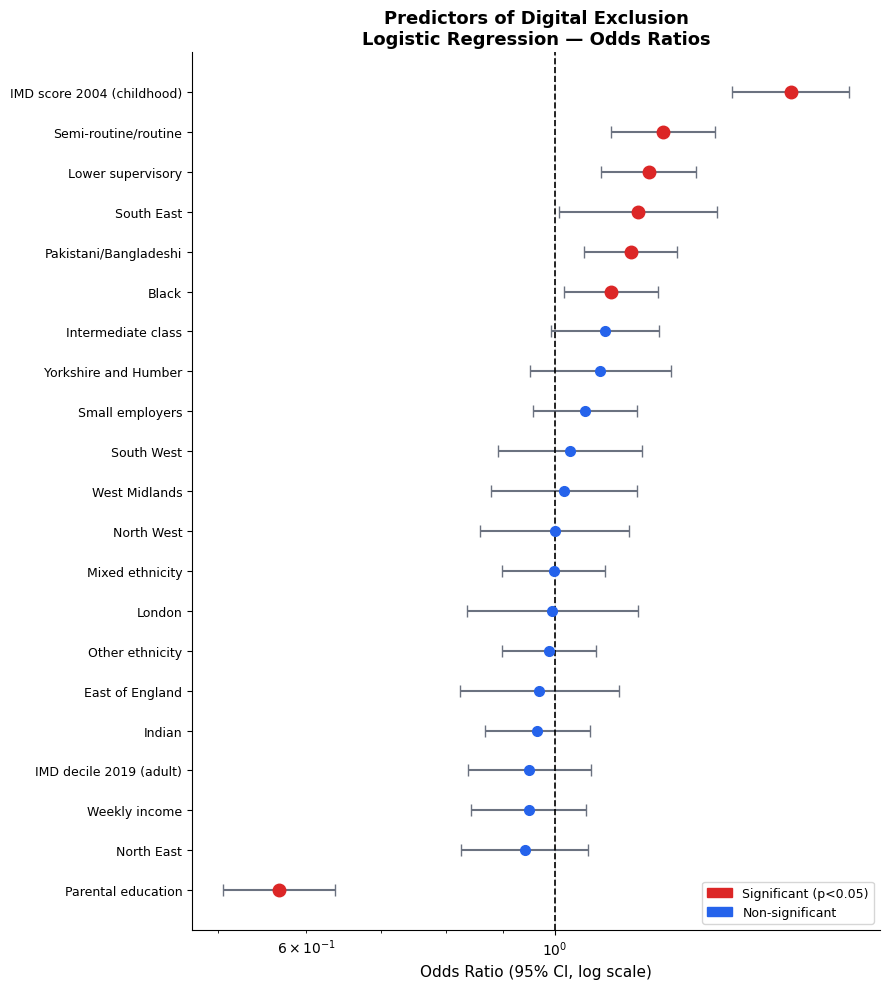

  Saved: fig2_forest_plot.png


In [ ]:
LABEL_MAP = {
    'parent_education': 'Parental education',
    'imd_score_2004':   'IMD score 2004 (childhood)',
    'imd_decile_2019':  'IMD decile 2019 (adult)',
    'W8DINCB':          'Weekly income',
    'eth_2': 'Mixed ethnicity',
    'eth_3': 'Indian',
    'eth_4': 'Pakistani/Bangladeshi',
    'eth_5': 'Black',
    'eth_6': 'Other ethnicity',
    'reg_London':                    'London',
    'reg_North East':                'North East',
    'reg_North West':                'North West',
    'reg_South East':                'South East',
    'reg_South West':                'South West',
    'reg_West Midlands':             'West Midlands',
    'reg_Yorkshire and The Humber':  'Yorkshire and Humber',
    'reg_East of England':           'East of England',
    'cls_2.0': 'Intermediate class',
    'cls_3.0': 'Small employers',
    'cls_4.0': 'Lower supervisory',
    'cls_5.0': 'Semi-routine/routine',
}

plot_df = lr_results.copy()
plot_df['label'] = plot_df.index.map(LABEL_MAP)
plot_df = plot_df.dropna(subset=['label']).sort_values('OR')

fig2, ax2 = plt.subplots(figsize=(9, 10))
y_pos = np.arange(len(plot_df))

colors_lr = [RED if row['p_approx'] < 0.05 else GREY
             for _, row in plot_df.iterrows()]
ax2.errorbar(
    plot_df['OR'], y_pos,
    xerr=[plot_df['OR'] - plot_df['CI_low'],
          plot_df['CI_high'] - plot_df['OR']],
    fmt='o', color=BLUE, ecolor=GREY,
    capsize=4, markersize=7, linewidth=1.5
)
# Colour significant points
for i, (_, row) in enumerate(plot_df.iterrows()):
    if row['p_approx'] < 0.05:
        ax2.plot(row['OR'], i, 'o', color=RED, markersize=9, zorder=5)

ax2.axvline(1, color='black', linestyle='--', lw=1.2)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_df['label'], fontsize=9)
ax2.set_xscale('log')
ax2.set_xlabel("Odds Ratio (95% CI, log scale)", fontsize=11)
ax2.set_title("Predictors of Digital Exclusion\n"
              "Logistic Regression — Odds Ratios",
              fontweight='bold')

sig_patch   = mpatches.Patch(color=RED,  label='Significant (p<0.05)')
insig_patch = mpatches.Patch(color=BLUE, label='Non-significant')
ax2.legend(handles=[sig_patch, insig_patch], fontsize=9, loc='lower right')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_forest_plot.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("  Saved: fig2_forest_plot.png")

LASSO Coefficient plots

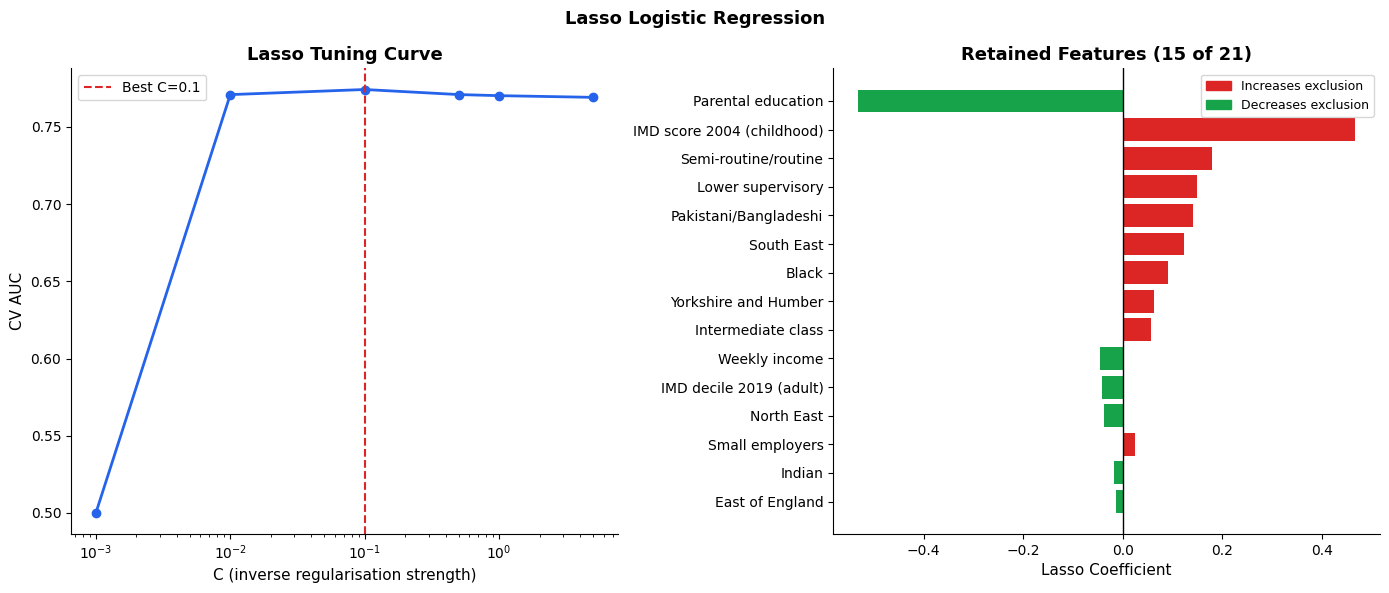

  Saved: fig3_lasso.png


In [ ]:
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle("Lasso Logistic Regression", fontweight='bold', fontsize=13)

# Left: tuning curve
Cs     = sorted(lasso_cv_scores.keys())
scores = [lasso_cv_scores[c] for c in Cs]
axes3[0].plot(Cs, scores, 'o-', color=BLUE, lw=2)
axes3[0].axvline(best_C, color=RED, linestyle='--',
                  label=f'Best C={best_C}')
axes3[0].set_xscale('log')
axes3[0].set_xlabel("C (inverse regularisation strength)")
axes3[0].set_ylabel("CV AUC")
axes3[0].set_title("Lasso Tuning Curve", fontweight='bold')
axes3[0].legend()

# Right: retained coefficients
ret_plot = retained.sort_values(key=abs)
bar_colors = [RED if c > 0 else GREEN for c in ret_plot.values]
axes3[1].barh(
    [LABEL_MAP.get(f, f) for f in ret_plot.index],
    ret_plot.values, color=bar_colors
)
axes3[1].axvline(0, color='black', lw=1)
axes3[1].set_xlabel("Lasso Coefficient")
axes3[1].set_title(f"Retained Features ({len(retained)} of "
                    f"{len(lasso_coefs)})", fontweight='bold')
inc_patch = mpatches.Patch(color=RED,   label='Increases exclusion')
dec_patch = mpatches.Patch(color=GREEN, label='Decreases exclusion')
axes3[1].legend(handles=[inc_patch, dec_patch], fontsize=9)

plt.tight_layout()
plt.savefig('fig3_lasso.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("  Saved: fig3_lasso.png")


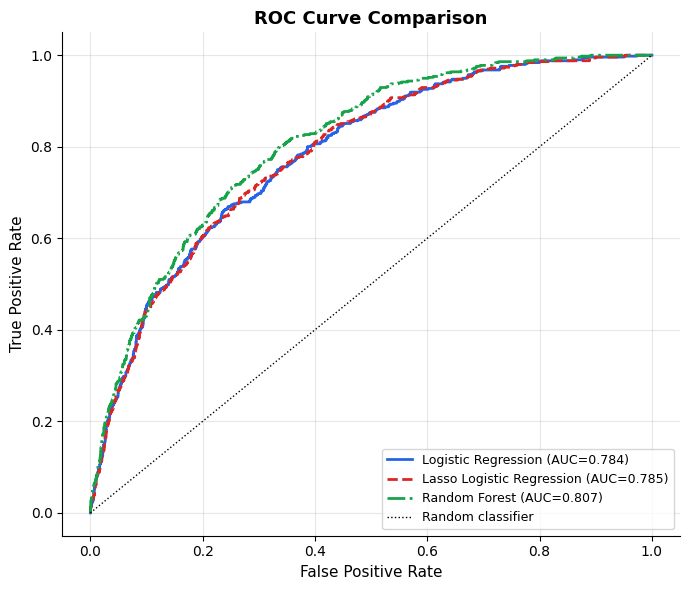

  Saved: fig5_roc_comparison.png


In [ ]:
fig5, ax5 = plt.subplots(figsize=(7, 6))

model_styles = {
    'Logistic Regression':       (BLUE,  '-'),
    'Lasso Logistic Regression': (RED,   '--'),
    'Random Forest':             (GREEN, '-.'),
}
for name, model in models.items():
    probs       = model.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y, probs)
    auc         = roc_auc_score(y, probs)
    color, ls   = model_styles[name]
    ax5.plot(fpr, tpr, color=color, ls=ls, lw=2,
             label=f"{name} (AUC={auc:.3f})")

ax5.plot([0, 1], [0, 1], 'k:', lw=1, label='Random classifier')
ax5.set_xlabel("False Positive Rate")
ax5.set_ylabel("True Positive Rate")
ax5.set_title("ROC Curve Comparison", fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_roc_comparison.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("  Saved: fig5_roc_comparison.png")

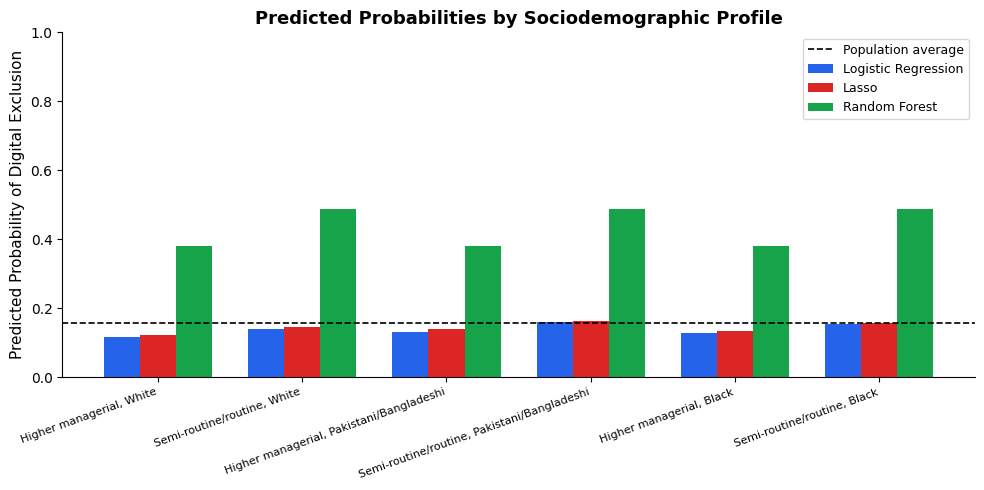

  Saved: fig6_predicted_probs.png


In [ ]:
fig6, ax6 = plt.subplots(figsize=(10, 5))

prof_names = list(profile_results.keys())
lr_probs   = [profile_results[p]['LR']    for p in prof_names]
lasso_probs= [profile_results[p]['Lasso'] for p in prof_names]
rf_probs   = [profile_results[p]['RF']    for p in prof_names]

x       = np.arange(len(prof_names))
width   = 0.25
ax6.bar(x - width, lr_probs,    width, label='Logistic Regression', color=BLUE)
ax6.bar(x,         lasso_probs, width, label='Lasso',               color=RED)
ax6.bar(x + width, rf_probs,    width, label='Random Forest',       color=GREEN)

ax6.axhline(analysis_df['digital_exclusion'].mean(), color='black',
             linestyle='--', lw=1.2, label='Population average')
ax6.set_xticks(x)
ax6.set_xticklabels(prof_names, rotation=20, ha='right', fontsize=8)
ax6.set_ylabel("Predicted Probability of Digital Exclusion")
ax6.set_title("Predicted Probabilities by Sociodemographic Profile",
               fontweight='bold')
ax6.legend(fontsize=9)
ax6.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig6_predicted_probs.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("  Saved: fig6_predicted_probs.png")

In [ ]:
print("\n" + "=" * 65)
print("SECTION 13 — SUMMARY OF KEY FINDINGS")
print("=" * 65)

best_model = max(cv_results, key=lambda k: cv_results[k]['auc_mean'])
print(f"\nBest performing model (CV AUC): {best_model} "
      f"({cv_results[best_model]['auc_mean']:.4f})")

print(f"\nLasso retained {len(retained)} predictors — "
      f"strongest (by |coef|):")
for feat in retained.head(5).index:
    print(f"  {LABEL_MAP.get(feat, feat)}: coef={retained[feat]:.3f}")

print(f"\nRandom Forest top 3 predictors (permutation importance):")
for feat in rf_imp_df.head(3).index:
    print(f"  {LABEL_MAP.get(feat, feat)}: {rf_imp_df.loc[feat,'importance']:.4f}")

sig_lr = lr_results[lr_results['p_approx'] < 0.05]
print(f"\nLogistic Regression: {len(sig_lr)} significant predictors (p<0.05)")


SECTION 13 — SUMMARY OF KEY FINDINGS

Best performing model (CV AUC): Lasso Logistic Regression (0.7742)

Lasso retained 15 predictors — strongest (by |coef|):
  Parental education: coef=-0.532
  IMD score 2004 (childhood): coef=0.467
  Semi-routine/routine: coef=0.179
  Lower supervisory: coef=0.150
  Pakistani/Bangladeshi: coef=0.142

Random Forest top 3 predictors (permutation importance):
  IMD score 2004 (childhood): 0.1078
  Parental education: 0.0658
  IMD decile 2019 (adult): 0.0106

Logistic Regression: 7 significant predictors (p<0.05)



SECTION 15 — ELASTIC NET LOGISTIC REGRESSION

Grid search (5-fold CV):
         C    l1_ratio    CV AUC
     0.001         0.1    0.7724 <-- best
     0.001         0.3    0.5000
     0.001         0.5    0.5000
     0.001         0.7    0.5000
     0.001         0.9    0.5000
      0.01         0.1    0.7756 <-- best
      0.01         0.3    0.7759 <-- best
      0.01         0.5    0.7741
      0.01         0.7    0.7722
      0.01         0.9    0.7707
       0.1         0.1    0.7707
       0.1         0.3    0.7719
       0.1         0.5    0.7726
       0.1         0.7    0.7734
       0.1         0.9    0.7739
       0.5         0.1    0.7694
       0.5         0.3    0.7698
       0.5         0.5    0.7702
       0.5         0.7    0.7706
       0.5         0.9    0.7708
       1.0         0.1    0.7691
       1.0         0.3    0.7693
       1.0         0.5    0.7697
       1.0         0.7    0.7699
       1.0         0.9    0.7702
       5.0         0.1    0.7689
       5.0

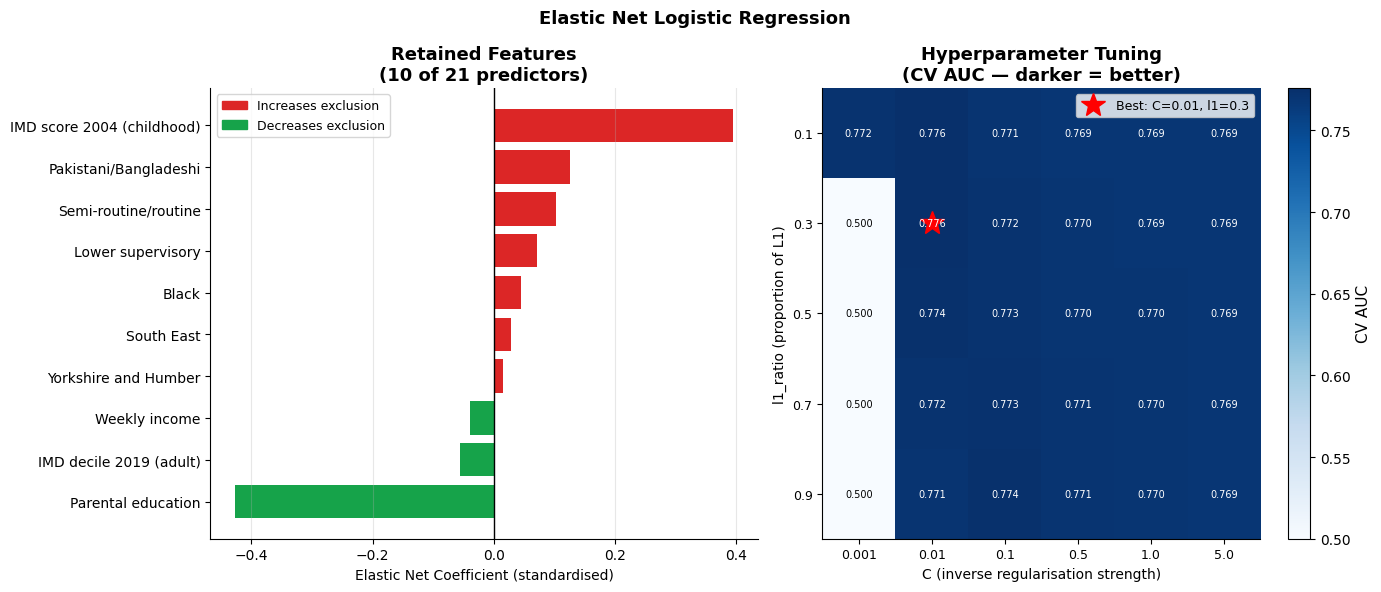


  Saved: fig8_elastic_net.png

Full analysis complete — all 8 figures saved.


In [ ]:
# SECTION 15: ELASTIC NET LOGISTIC REGRESSION
# Combines L1 (variable selection) + L2 (handles correlated
# predictors) — better suited than Lasso when predictors are
# correlated (e.g. social class, income, parental education)
# ================================================================

print("\n" + "=" * 65)
print("SECTION 15 — ELASTIC NET LOGISTIC REGRESSION")
print("=" * 65)

# ── Hyperparameter tuning ────────────────────────────────────────
C_values        = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
l1_ratio_values = [0.1, 0.3, 0.5, 0.7, 0.9]

print("\nGrid search (5-fold CV):")
print(f"  {'C':>8}  {'l1_ratio':>10}  {'CV AUC':>8}")

best_en_score  = 0
best_C_en      = None
best_l1_en     = None
tuning_results = []

for C in C_values:
    for l1_ratio in l1_ratio_values:
        en_tmp = LogisticRegression(
            penalty='elasticnet', solver='saga',
            C=C, l1_ratio=l1_ratio,
            max_iter=2000, random_state=42
        )
        score = cross_val_score(en_tmp, X_scaled, y, cv=cv,
                                scoring='roc_auc').mean()
        tuning_results.append({'C': C, 'l1_ratio': l1_ratio, 'auc': score})
        if score > best_en_score:
            best_en_score = score
            best_C_en     = C
            best_l1_en    = l1_ratio
        print(f"  {C:>8}  {l1_ratio:>10}  {score:>8.4f}"
              + (" <-- best" if score == best_en_score else ""))

print(f"\nBest hyperparameters: C={best_C_en}, l1_ratio={best_l1_en}")
print(f"Best CV AUC:          {best_en_score:.4f}")
print(f"Mix: {best_l1_en*100:.0f}% L1 (Lasso) + {(1-best_l1_en)*100:.0f}% L2 (Ridge)")

# ── Fit final Elastic Net ────────────────────────────────────────
en = LogisticRegression(
    penalty='elasticnet', solver='saga',
    C=best_C_en, l1_ratio=best_l1_en,
    max_iter=2000, random_state=42
)
en.fit(X_scaled, y)

en_coefs  = pd.Series(en.coef_[0], index=X_scaled.columns)
retained_en = en_coefs[en_coefs != 0].sort_values(key=abs, ascending=False)
zeroed_en   = en_coefs[en_coefs == 0]

print(f"\nElastic Net retained {len(retained_en)} / {len(en_coefs)} features")
print(f"Zeroed out:          {len(zeroed_en)} features")

print("\nRetained features (sorted by |coefficient|):")
print(f"  {'Feature':35s}  {'Coef':>8}  {'OR':>6}  Direction")
for feat, coef in retained_en.items():
    direction = 'increases exclusion' if coef > 0 else 'decreases exclusion'
    label     = LABEL_MAP.get(feat, feat)
    print(f"  {label:35s}  {coef:8.4f}  {np.exp(coef):6.3f}  {direction}")

if len(zeroed_en) > 0:
    print(f"\nZeroed-out (weakest predictors):")
    for f in zeroed_en.index:
        print(f"  {LABEL_MAP.get(f, f)}")

# ── Update model comparison table ───────────────────────────────
print("\n" + "=" * 65)
print("UPDATED MODEL COMPARISON (including Elastic Net)")
print("=" * 65)

models['Elastic Net'] = en
print(f"\n{'Model':30s}  {'CV AUC':>8}  {'±SD':>6}  {'CV Acc':>8}")
for name, model in models.items():
    auc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    print(f"{name:30s}  {auc_scores.mean():.4f}  "
          f"±{auc_scores.std():.4f}  {acc_scores.mean():.4f}")

# ── FIGURE 8: Elastic Net results ───────────────────────────────
tuning_df = pd.DataFrame(tuning_results)
pivot     = tuning_df.pivot(index='l1_ratio', columns='C', values='auc')

fig8, axes8 = plt.subplots(1, 2, figsize=(14, 6))
fig8.suptitle("Elastic Net Logistic Regression",
               fontsize=13, fontweight='bold')

# Left: retained coefficient bar chart
ret_plot_en   = retained_en.sort_values()
bar_colors_en = [RED if c > 0 else GREEN for c in ret_plot_en.values]
labels_en     = [LABEL_MAP.get(f, f) for f in ret_plot_en.index]

axes8[0].barh(labels_en, ret_plot_en.values, color=bar_colors_en)
axes8[0].axvline(0, color='black', lw=1)
axes8[0].set_xlabel("Elastic Net Coefficient (standardised)", fontsize=10)
axes8[0].set_title(
    f"Retained Features\n({len(retained_en)} of {len(en_coefs)} predictors)",
    fontweight='bold'
)
inc_patch = mpatches.Patch(color=RED,   label='Increases exclusion')
dec_patch = mpatches.Patch(color=GREEN, label='Decreases exclusion')
axes8[0].legend(handles=[inc_patch, dec_patch], fontsize=9)
axes8[0].grid(axis='x', alpha=0.3)

# Right: tuning heatmap
im8 = axes8[1].imshow(pivot.values, aspect='auto', cmap='Blues',
                       vmin=pivot.values.min(), vmax=pivot.values.max())
axes8[1].set_xticks(range(len(C_values)))
axes8[1].set_xticklabels(C_values, fontsize=9)
axes8[1].set_yticks(range(len(l1_ratio_values)))
axes8[1].set_yticklabels(l1_ratio_values, fontsize=9)
axes8[1].set_xlabel("C (inverse regularisation strength)", fontsize=10)
axes8[1].set_ylabel("l1_ratio (proportion of L1)", fontsize=10)
axes8[1].set_title("Hyperparameter Tuning\n(CV AUC — darker = better)",
                    fontweight='bold')

best_col_en = C_values.index(best_C_en)
best_row_en = l1_ratio_values.index(best_l1_en)
axes8[1].plot(best_col_en, best_row_en, 'r*', markersize=18,
               label=f'Best: C={best_C_en}, l1={best_l1_en}')
axes8[1].legend(fontsize=9)

for i in range(len(l1_ratio_values)):
    for j in range(len(C_values)):
        axes8[1].text(j, i, f'{pivot.values[i,j]:.3f}',
                       ha='center', va='center', fontsize=7,
                       color='white' if pivot.values[i,j] > pivot.values.mean()
                       else 'black')

plt.colorbar(im8, ax=axes8[1], label='CV AUC')
plt.tight_layout()
plt.savefig('fig8_elastic_net.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n  Saved: fig8_elastic_net.png")
print("\nFull analysis complete — all 8 figures saved.")